# Exercise 6: Multimodal Music Classification

## Imports

In [8]:
import pathlib
from dataclasses import dataclass
from typing import List, Dict, Any

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from skimage import io, color, feature
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split


## Constants

In [9]:
current_dir = pathlib.Path.cwd()

# Dataset
dataset_path = current_dir.joinpath("data", "Dataset_Exercise_6")
classical_pieces_path = dataset_path.joinpath("Classical")
rock_pieces_path = dataset_path.joinpath("Rock")

# File extensions
AUDIO_FILE_EXTENSION = ".mp3"
IMAGE_FILE_EXTENSION = ".webp"

N_CLASSIFIERS = 300

SEED = 0

# DF
TARGET_COLUMN = "label"
ID_COLUMN = "song_id"

CLASSICAL_LABEL = "Classical"
ROCK_LABEL = "Rock"

## Read and process dataset

In [10]:
@dataclass
class SongInfo:
    song_id: str
    audio_file_path: pathlib.Path
    image_file_path: pathlib.Path


def get_piece_info_list(data_path: pathlib.Path) -> List[SongInfo]:
    song_info = []
    for audio_file in data_path.glob(f"*{AUDIO_FILE_EXTENSION}"):
        image_file = audio_file.with_suffix(IMAGE_FILE_EXTENSION)
        if not image_file.is_file():
            raise RuntimeError(f"Image file {image_file} not found.")

        song_info.append(SongInfo(
            song_id=image_file.stem,
            audio_file_path=audio_file,
            image_file_path=image_file
        ))
    return song_info


classical_pieces_info = get_piece_info_list(classical_pieces_path)
rock_pieces_info = get_piece_info_list(rock_pieces_path)

## E1: Genre Classification with Album Images

In [11]:
def get_img_features(img_path: pathlib.Path) -> Dict[str, Any]:
    img_rgb = io.imread(img_path)

    # HSV values
    hsv_img = color.rgb2hsv(img_rgb)
    H, S, V = hsv_img[:, :, 0], hsv_img[:, :, 1], hsv_img[:, :, 2]

    # CANNY EDGES
    img_gray = color.rgb2gray(img_rgb)
    edges = feature.canny(img_gray)
    edge_density = np.sum(edges) / edges.size

    return {
        "H_mean": np.mean(H),
        "H_var": np.var(H),
        "S_mean": np.mean(S),
        "S_var": np.var(S),
        "V_mean": np.mean(V),
        "V_var": np.var(V),
        "edge_density": edge_density,
    }


def get_img_features_df(pieces_info: List[SongInfo], label: str) -> pd.DataFrame:
    row_list = []
    for piece_info in pieces_info:
        features = get_img_features(piece_info.image_file_path)
        features[ID_COLUMN] = piece_info.song_id
        features[TARGET_COLUMN] = label
        row_list.append(features)

    df = pd.DataFrame(row_list)
    df.set_index(ID_COLUMN, inplace=True)
    return df


classical_img_df = get_img_features_df(classical_pieces_info, label=CLASSICAL_LABEL)
rock_img_df = get_img_features_df(rock_pieces_info, label=ROCK_LABEL)

print(classical_img_df.head())
print(rock_img_df.head())

                                                      H_mean     H_var  \
song_id                                                                  
Milton Mallawarachchi - Pem Rajadahane Indrani ...  0.247367  0.159703   
Serge Quadrado - Forget your Dream                  0.031005  0.024876   
Lovira - Birthday present                           0.005153  0.004267   
Blue Dot Sessions - Sudden Uncertainty              0.692710  0.012144   
Serge Quadrado - Celebration of Life                0.147150  0.070884   

                                                      S_mean         S_var  \
song_id                                                                      
Milton Mallawarachchi - Pem Rajadahane Indrani ...  0.270964  1.577961e-01   
Serge Quadrado - Forget your Dream                  0.000161  7.267225e-07   
Lovira - Birthday present                           0.000025  9.676374e-08   
Blue Dot Sessions - Sudden Uncertainty              0.429693  5.139023e-02   
Serge Quadrad

In [12]:
def train_test_classifiers(classical_df: pd.DataFrame, rock_df: pd.DataFrame, train_size: int = 15,
                           test_size: int = 5) -> pd.DataFrame:
    results_list = []
    for i, seed in enumerate(range(SEED, SEED + N_CLASSIFIERS)):
        if i % 10 == 0:
            print(f"{i} / {N_CLASSIFIERS} - {100 * i / N_CLASSIFIERS:.2f}%")

        train_15c, test_5c = train_test_split(classical_df, train_size=train_size, test_size=test_size,
                                              random_state=seed)
        train_15r, test_5r = train_test_split(rock_df, train_size=train_size, test_size=test_size, random_state=seed)
        train_df = pd.concat([train_15c, train_15r])
        test_df = pd.concat([test_5c, test_5r])

        X = train_df.drop(columns=[TARGET_COLUMN])
        Y = train_df[TARGET_COLUMN]

        clf = RandomForestClassifier(random_state=seed)
        clf = clf.fit(X, Y)

        x = test_df.drop(columns=[TARGET_COLUMN])
        y = test_df[TARGET_COLUMN]

        y_pred = clf.predict(x)

        results_list.append({
            "model_name": seed,
            "accuracy": (accuracy_score(y, y_pred)),
            "f1_score": (f1_score(y, y_pred, average='weighted'))
        })

    return pd.DataFrame(results_list)


results_img_df = train_test_classifiers(classical_img_df, rock_img_df)
print(results_img_df.head())

0 / 300 - 0.00%
10 / 300 - 3.33%
20 / 300 - 6.67%
30 / 300 - 10.00%
40 / 300 - 13.33%
50 / 300 - 16.67%
60 / 300 - 20.00%
70 / 300 - 23.33%
80 / 300 - 26.67%
90 / 300 - 30.00%
100 / 300 - 33.33%
110 / 300 - 36.67%
120 / 300 - 40.00%
130 / 300 - 43.33%
140 / 300 - 46.67%
150 / 300 - 50.00%
160 / 300 - 53.33%
170 / 300 - 56.67%
180 / 300 - 60.00%
190 / 300 - 63.33%
200 / 300 - 66.67%
210 / 300 - 70.00%
220 / 300 - 73.33%
230 / 300 - 76.67%
240 / 300 - 80.00%
250 / 300 - 83.33%
260 / 300 - 86.67%
270 / 300 - 90.00%
280 / 300 - 93.33%
290 / 300 - 96.67%
   model_name  accuracy  f1_score
0           0       0.6  0.600000
1           1       0.4  0.375000
2           2       0.3  0.292929
3           3       0.4  0.400000
4           4       0.5  0.450549


In [13]:
def compute_metrics(results_df: pd.DataFrame) -> Dict[str, float]:
    return {
        "mean_accuracy": (results_df["accuracy"].mean()),
        "mean_f1_score": (results_df["f1_score"].mean())
    }


def visualize_metrics(metrics: Dict[str, float]) -> None:
    for key, value in metrics.items():
        print(f"{key}: {value:.3f}")


img_metrics = compute_metrics(results_img_df)
visualize_metrics(img_metrics)

mean_accuracy: 0.503
mean_f1_score: 0.488


## E2: Genre Classification with MFCCs

In [14]:
def get_audio_features(song_path: pathlib.Path) -> Dict[str, Any]:
    y, sr = librosa.load(song_path)
    mfcc = librosa.feature.mfcc(y=y, sr=sr)
    first_four = mfcc[:4, :]

    means = np.mean(first_four, axis=1)
    vars_ = np.var(first_four, axis=1)

    return {
        **{f"mfcc_mean_{i + 1}": means[i] for i in range(4)},
        **{f"mfcc_var_{i + 1}": vars_[i] for i in range(4)},
    }


def get_audio_features_df(song_info_list: List[SongInfo], label: str) -> pd.DataFrame:
    row_list = []

    for song_info in song_info_list:
        features = get_audio_features(song_info.audio_file_path)
        features[ID_COLUMN] = song_info.song_id
        features[TARGET_COLUMN] = label
        row_list.append(features)

    df = pd.DataFrame(row_list)
    df.set_index(ID_COLUMN, inplace=True)
    return df


classical_audio_df = get_audio_features_df(classical_pieces_info, label=CLASSICAL_LABEL)
rock_audio_df = get_audio_features_df(rock_pieces_info, label=ROCK_LABEL)

print(classical_audio_df.head())
print(rock_audio_df.head())

                                                    mfcc_mean_1  mfcc_mean_2  \
song_id                                                                        
Milton Mallawarachchi - Pem Rajadahane Indrani ...  -148.053848    94.176270   
Serge Quadrado - Forget your Dream                  -388.852600   206.969055   
Lovira - Birthday present                           -288.216278   126.465958   
Blue Dot Sessions - Sudden Uncertainty              -361.319885   124.684731   
Serge Quadrado - Celebration of Life                -216.117981   110.188042   

                                                    mfcc_mean_3  mfcc_mean_4  \
song_id                                                                        
Milton Mallawarachchi - Pem Rajadahane Indrani ...   -13.235594    41.065945   
Serge Quadrado - Forget your Dream                     6.608006   -11.251152   
Lovira - Birthday present                            -25.459698    19.815750   
Blue Dot Sessions - Sudden Uncertainty 

In [15]:
results_audio_df = train_test_classifiers(classical_audio_df, rock_audio_df)

0 / 300 - 0.00%
10 / 300 - 3.33%
20 / 300 - 6.67%
30 / 300 - 10.00%
40 / 300 - 13.33%
50 / 300 - 16.67%
60 / 300 - 20.00%
70 / 300 - 23.33%
80 / 300 - 26.67%
90 / 300 - 30.00%
100 / 300 - 33.33%
110 / 300 - 36.67%
120 / 300 - 40.00%
130 / 300 - 43.33%
140 / 300 - 46.67%
150 / 300 - 50.00%
160 / 300 - 53.33%
170 / 300 - 56.67%
180 / 300 - 60.00%
190 / 300 - 63.33%
200 / 300 - 66.67%
210 / 300 - 70.00%
220 / 300 - 73.33%
230 / 300 - 76.67%
240 / 300 - 80.00%
250 / 300 - 83.33%
260 / 300 - 86.67%
270 / 300 - 90.00%
280 / 300 - 93.33%
290 / 300 - 96.67%


In [16]:
audio_metrics = compute_metrics(results_audio_df)
visualize_metrics(audio_metrics)

mean_accuracy: 0.840
mean_f1_score: 0.837


## E3: Genre Classification with Album Images and MFCCs

In [17]:
def merge_df(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat([df1, df2], axis=1)
    df = df.loc[:, ~df.columns.duplicated()]
    return df


classical_merged_df = merge_df(classical_img_df, classical_audio_df)
rock_merged_df = merge_df(rock_img_df, rock_audio_df)

print(classical_merged_df.head())
print(rock_merged_df.head())

                                                      H_mean     H_var  \
song_id                                                                  
Milton Mallawarachchi - Pem Rajadahane Indrani ...  0.247367  0.159703   
Serge Quadrado - Forget your Dream                  0.031005  0.024876   
Lovira - Birthday present                           0.005153  0.004267   
Blue Dot Sessions - Sudden Uncertainty              0.692710  0.012144   
Serge Quadrado - Celebration of Life                0.147150  0.070884   

                                                      S_mean         S_var  \
song_id                                                                      
Milton Mallawarachchi - Pem Rajadahane Indrani ...  0.270964  1.577961e-01   
Serge Quadrado - Forget your Dream                  0.000161  7.267225e-07   
Lovira - Birthday present                           0.000025  9.676374e-08   
Blue Dot Sessions - Sudden Uncertainty              0.429693  5.139023e-02   
Serge Quadrad

In [18]:
final_results_df = train_test_classifiers(classical_merged_df, rock_merged_df)

0 / 300 - 0.00%
10 / 300 - 3.33%
20 / 300 - 6.67%
30 / 300 - 10.00%
40 / 300 - 13.33%
50 / 300 - 16.67%
60 / 300 - 20.00%
70 / 300 - 23.33%
80 / 300 - 26.67%
90 / 300 - 30.00%
100 / 300 - 33.33%
110 / 300 - 36.67%
120 / 300 - 40.00%
130 / 300 - 43.33%
140 / 300 - 46.67%
150 / 300 - 50.00%
160 / 300 - 53.33%
170 / 300 - 56.67%
180 / 300 - 60.00%
190 / 300 - 63.33%
200 / 300 - 66.67%
210 / 300 - 70.00%
220 / 300 - 73.33%
230 / 300 - 76.67%
240 / 300 - 80.00%
250 / 300 - 83.33%
260 / 300 - 86.67%
270 / 300 - 90.00%
280 / 300 - 93.33%
290 / 300 - 96.67%


In [19]:
final_metrics = compute_metrics(final_results_df)
visualize_metrics(final_metrics)

mean_accuracy: 0.826
mean_f1_score: 0.822


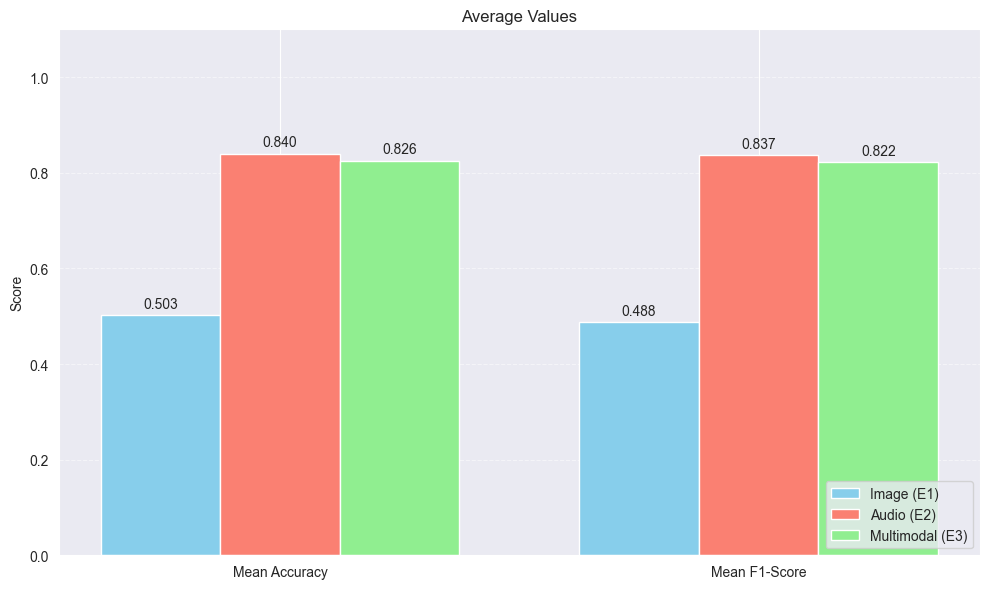

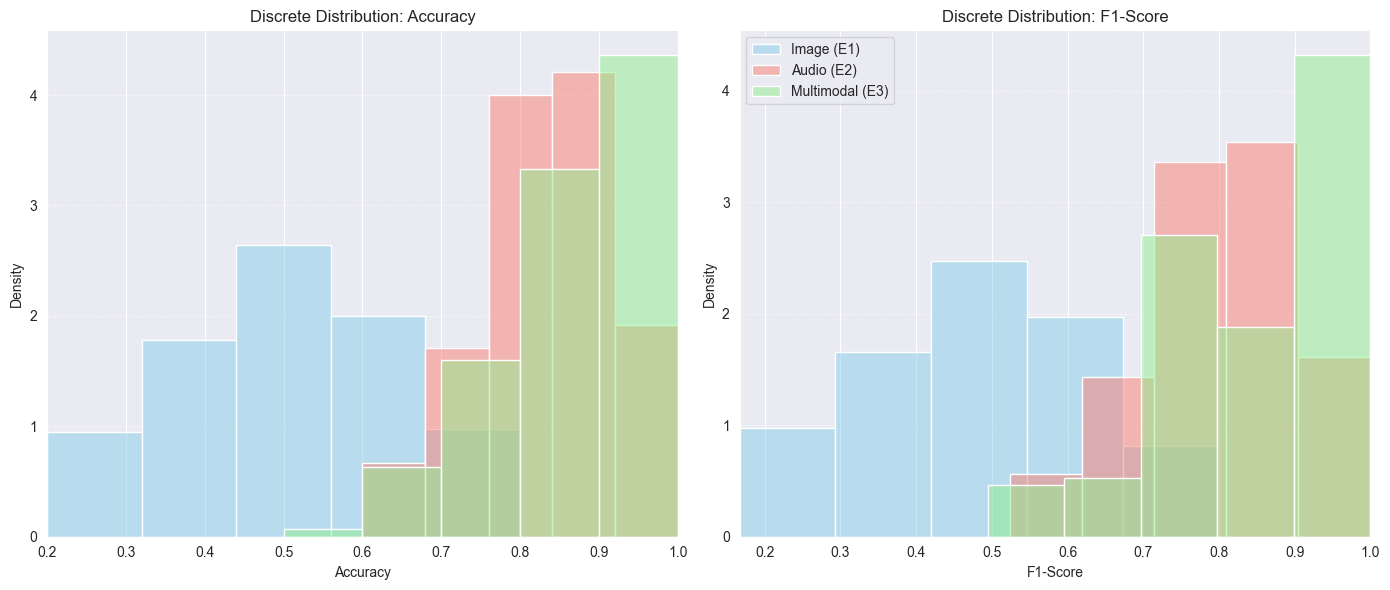

In [20]:
def plot_comparison(img_df, audio_df, multimodal_df):
    datasets = [img_df, audio_df, multimodal_df]
    labels = ["Image (E1)", "Audio (E2)", "Multimodal (E3)"]
    colors = ["skyblue", "salmon", "lightgreen"]

    mean_acc = [df["accuracy"].mean() for df in datasets]
    mean_f1 = [df["f1_score"].mean() for df in datasets]

    fig1, ax1 = plt.subplots(figsize=(10, 6))
    metric_labels = ["Mean Accuracy", "Mean F1-Score"]
    x = np.arange(len(metric_labels))
    width = 0.25

    vals_img = [mean_acc[0], mean_f1[0]]
    vals_audio = [mean_acc[1], mean_f1[1]]
    vals_multi = [mean_acc[2], mean_f1[2]]

    rects1 = ax1.bar(x - width, vals_img, width, label=labels[0], color=colors[0])
    rects2 = ax1.bar(x, vals_audio, width, label=labels[1], color=colors[1])
    rects3 = ax1.bar(x + width, vals_multi, width, label=labels[2], color=colors[2])

    ax1.set_ylabel("Score")
    ax1.set_title("Average Values")
    ax1.set_xticks(x)
    ax1.set_xticklabels(metric_labels)
    ax1.set_ylim(0, 1.1)
    ax1.legend(loc="lower right")
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    for rect in [rects1, rects2, rects3]:
        ax1.bar_label(rect, padding=3, fmt="%.3f")
    plt.tight_layout()
    plt.show()
    fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(14, 6))

    NUM_BINS = 5

    for i, df in enumerate(datasets):
        sns.histplot(
            data=df["accuracy"],
            ax=ax2,
            label=labels[i],
            color=colors[i],
            bins=NUM_BINS,
            shrink=1,
            stat="density",
            kde=False,
            element="bars",
            multiple="layer",
            alpha=0.5,
            edgecolor=None
        )

    ax2.set_title("Discrete Distribution: Accuracy")
    ax2.set_xlabel("Accuracy")
    ax2.set_ylabel("Density")
    ax2.grid(axis="y", linestyle="--", alpha=0.5)

    all_acc = pd.concat([d["accuracy"] for d in datasets])
    ax2.set_xlim(all_acc.min(), all_acc.max())

    for i, df in enumerate(datasets):
        sns.histplot(
            data=df["f1_score"],
            ax=ax3,
            label=labels[i],
            color=colors[i],
            bins=NUM_BINS,
            shrink=1,
            stat="density",
            kde=False,
            element="bars",
            multiple="layer",
            alpha=0.5,
            edgecolor=None
        )

    ax3.set_title("Discrete Distribution: F1-Score")
    ax3.set_xlabel("F1-Score")
    ax3.set_ylabel("Density")
    ax3.legend(loc="upper left")
    ax3.grid(axis="y", linestyle="--", alpha=0.5)

    all_f1 = pd.concat([d["f1_score"] for d in datasets])
    ax3.set_xlim(all_f1.min(), all_f1.max())

    plt.tight_layout()
    plt.show()


plot_comparison(results_img_df, results_audio_df, final_results_df)